# Exploratory Data Analysis of the Netflix Movies & TV Shows Dataset

**Author:** Your Name  
**Date:** 23 July 2026

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Netflix Movies & TV Shows dataset to understand its structure, clean the data, identify patterns, visualize trends, and extract meaningful insights using Python.

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np 

In [2]:
data=pd.read_csv("../data/NetFlix.csv")
pata=pd.read_csv("../data/NetFlix.csv")


In [3]:
data.sample(5)
data.head()
data.tail()
# pata.type.value_counts()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,6-Dec-16,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...


Section 1: Dataset Overview

-How many rows and columns are there?

-What are the data types?

-Which columns contain missing values?

-Are there duplicate rows?

In [4]:
#to get the shape 
data.shape

(7787, 12)

### So the data have 7708 columns and 12 rows

In [5]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='str')

##### Columns names = [ show_id, type, title, director, cast, country, date_added,  release_year, rating, duration, genres, description ]

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(2), str(10)
memory usage: 730.2 KB


In [21]:
data.describe()
# data.describe(include="object")

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


Section 2: Data Cleaning

Document every cleaning step.

Questions:

-Which columns contain missing values?

-How many missing values are there?

-Should we remove or fill them?

-Are there duplicate records?

-Are there inconsistent values?

In [8]:
# For calculating missing values
data.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

#### --The data has blank columns as 2389 for directors , 718 for cast , 500 for country , 10 for date_added and 7 for ratings .

In [9]:
#for duplicated rows 
data.duplicated().sum()

np.int64(0)

#### the data has no duplicated rows 

In [10]:
# to fill nans
data.fillna(0)
# u can remove them too
data.dropna()
# to check inconsistency 
data["type"].unique()
data["country"].unique()
# If there there was A lot of data with same name , values but due to them being small or big Letter they are consuming different spaces
data["country"] = data["country"].str.title()
data["country"].unique()

<StringArray>
[                                     'Brazil',
                                       'India',
                                   'Indonesia',
                               'United States',
                              'United Kingdom',
                       'United States, France',
                      'Germany, United States',
                                      'Canada',
                                       'Japan',
                                    'Thailand',
 ...
                               'Turkey, India',
                          'Philippines, Qatar',
                'Ireland, Luxembourg, Belgium',
 'Saudi Arabia, Syria, Egypt, Lebanon, Kuwait',
                       'Russia, United States',
       'United Kingdom, Russia, United States',
               'United States, France, Serbia',
                'Germany, Jordan, Netherlands',
                    'Argentina, United States',
                      'France, Belgium, Spain']
Length: 682, dtype: s

Section 3: Univariate Analysis (One column)

Type

How many Movies vs TV Shows are there?

What percentage of Netflix content is Movies?

What percentage of Netflix content is TV Shows?

In [11]:
a=pata[pata["type"]=="Movie"].shape[0]
b=pata[pata["type"]=="TV Show"].shape[0]
a>b , a<b

(True, False)

In [12]:
def percent(a):
    return f"{a/pata.shape[0]*100:.2f}%"
pata["type"].value_counts().apply(percent)
pata["type"].value_counts().apply(percent)["Movie"]
pata["type"].value_counts().apply(percent)["TV Show"]


'30.95%'

Rating

-Which rating appears most frequently?

-What are the top 10 ratings?

In [13]:
pata.rating.value_counts().head(1)

pata.rating.value_counts().head(10)


rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
TV-Y      280
TV-Y7     271
PG        247
TV-G      194
NR         84
Name: count, dtype: int64

Release Year

-Which year has the highest number of releases?

-What is the oldest title?

-What is the newest title?

In [14]:
pata.release_year.value_counts().head(1)
# pata.loc[pata["release_year"] == pata["release_year"].min(), "title"]
# pata.loc[pata["release_year"] == pata["release_year"].max(), "title"]
pata.loc[pata["release_year"].idxmin(), "title"]
pata.loc[pata["release_year"].idxmax(), "title"]



'Carmen Sandiego'

Duration

-What is the average movie duration?

-What is the shortest movie?

-What is the longest movie?

In [15]:
pata.duration.mean()
pata.loc[pata["duration"].idxmin(), "title"]
pata.loc[pata["duration"].idxmax(), "title"]


'Black Mirror: Bandersnatch'

Section 4: Country Analysis

This is one of the most interesting sections.

Questions:

Which countries produce the most Netflix content?

Top 10 countries?

Which country contributes the least?

How many countries are represented?

Are multiple countries listed for some titles?

In [16]:
# pata.head()
pata.country.value_counts().head(1)
pata.country.value_counts().head(10)
pata.country.value_counts().tail(10)
# pata.country.unique().shape[0]
countries=( pata.country.str.split(",").explode().str.strip())
countries.nunique()
pata[pata.country.str.contains(",",na=False)].shape[0]


# pata.loc[pata["country"].idxmin(), "country"]


1153

Section 5: Genre Analysis

Questions:

Which genre is most common?

Top 10 genres?

Which genres are rare?

Do Movies and TV Shows have different genre distributions?

<Axes: xlabel='genres'>

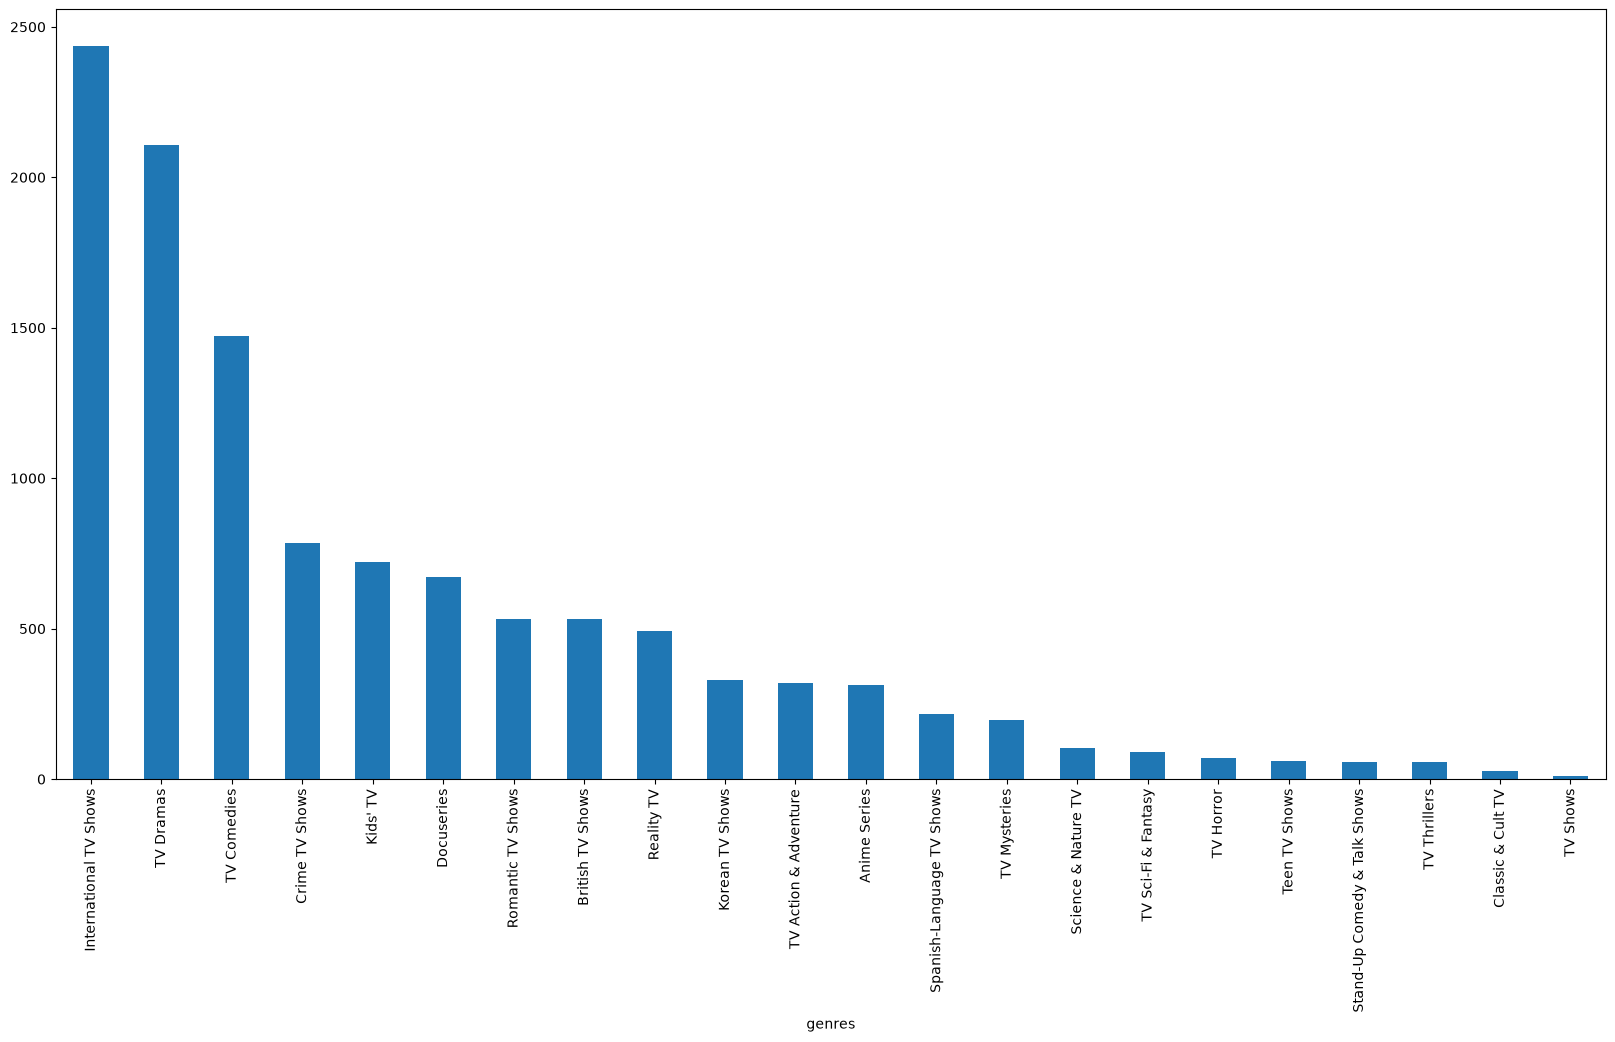

In [17]:
pata.genres.value_counts().head(1)
pata.genres.value_counts().head(10)
pata.genres.value_counts().tail(10)
# pata.head()
movies=pata[pata["type"]=="Movie"]
shows=pata[pata["type"]=="TV Show"]
shows_genres=shows.genres.str.split(",").explode().str.strip().value_counts()
movies_genres=movies.genres.str.split(",").explode().str.strip().value_counts()
movies_genres.plot(kind="bar",figsize=(20,10))
shows_genres.plot(kind="bar",figsize=(20,10))

# pata.genres[pata.type=="TV Show"].plot(kind="pie")


Section 6: Time Analysis

This tells the story of Netflix's growth.

Questions:

How many titles were released each year?

Which year had the highest number of releases?

How has content production changed over time?

Has Netflix shifted toward TV Shows?

<Axes: xlabel='release_year'>

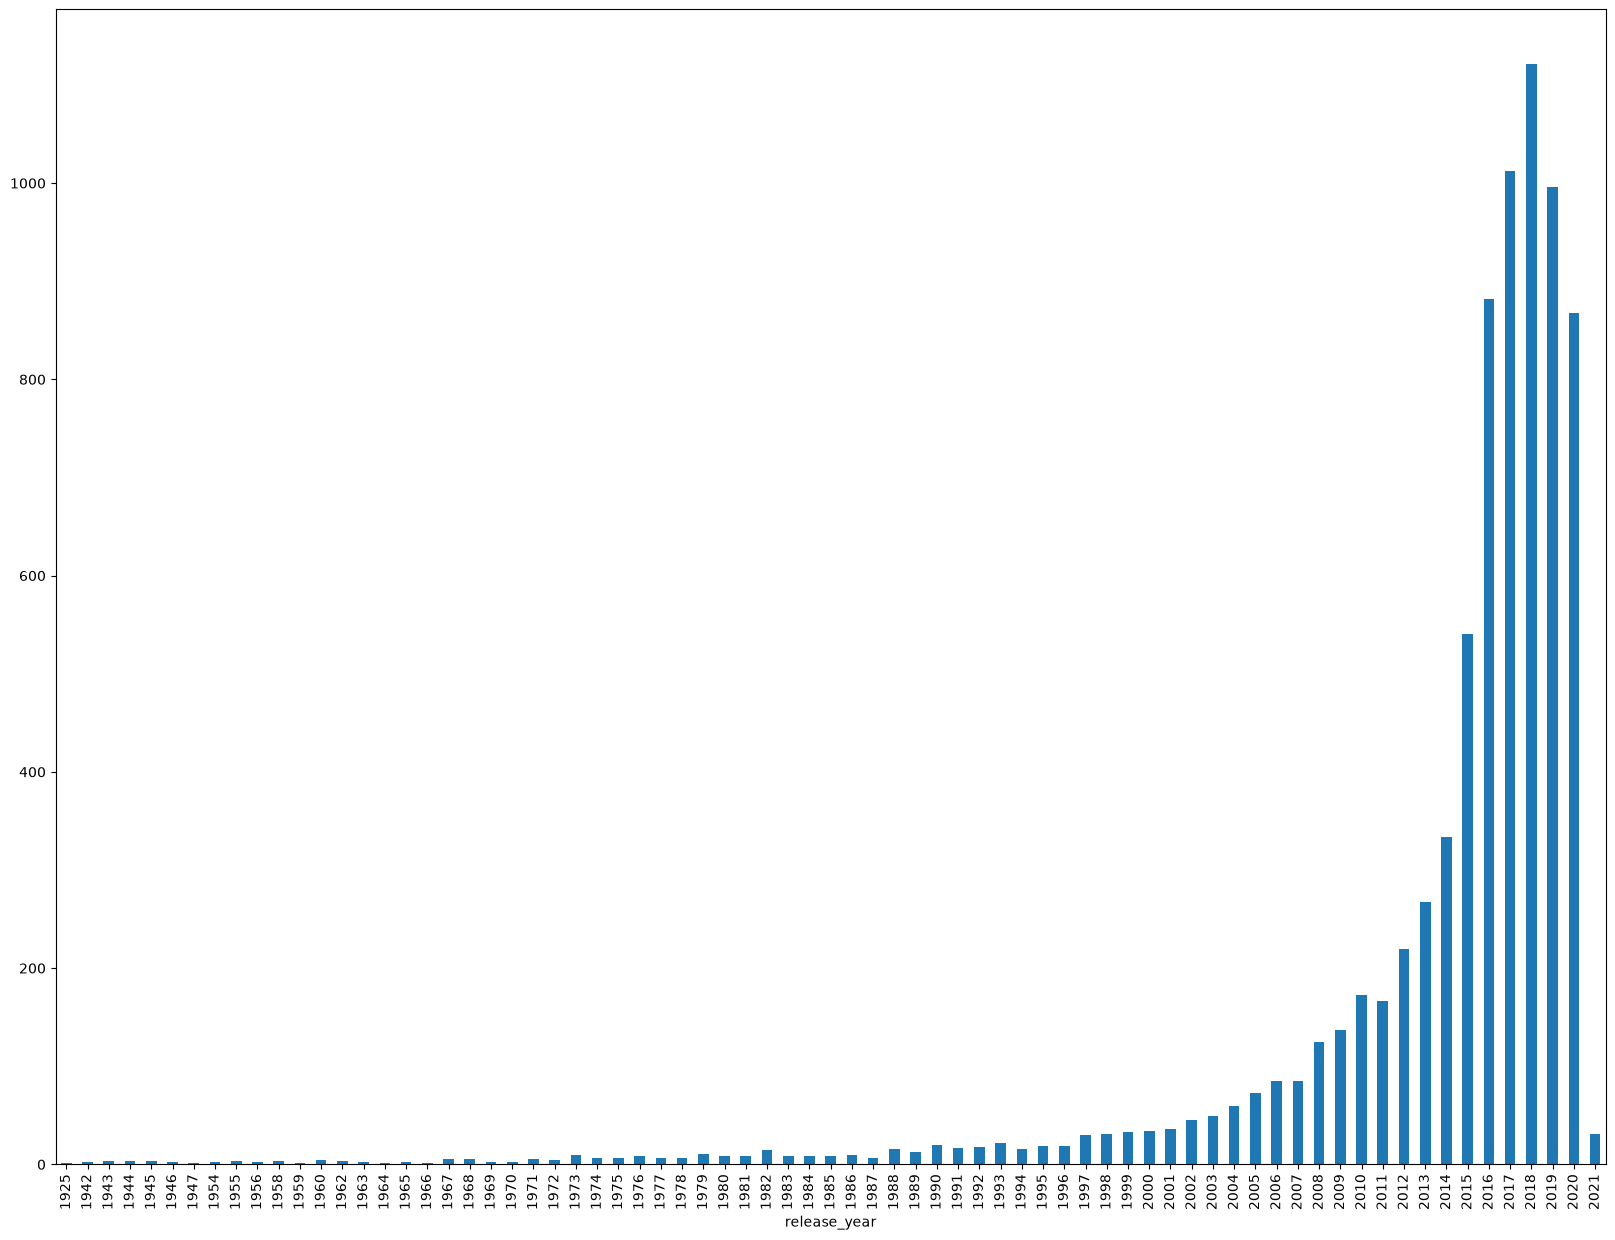

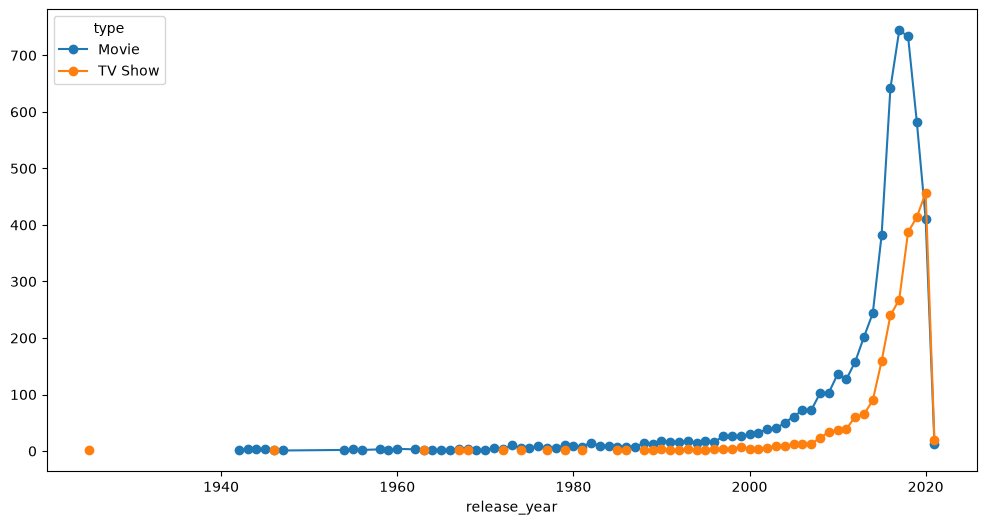

In [18]:
pata.release_year.value_counts()
pata.release_year.value_counts().head(1)
pata.release_year.value_counts().sort_index().plot(kind="bar",figsize=(20,15))
# shows.release_year.value_counts().sort_index().plot(kind="bar",figsize=(20,15))
# movies.release_year.value_counts().sort_index().plot(kind="bar",figsize=(20,15))
pata.groupby(["release_year", "type"]).size().unstack().plot(
    figsize=(12,6),
    marker="o"
)

<!--  -->

<Axes: xlabel='type'>

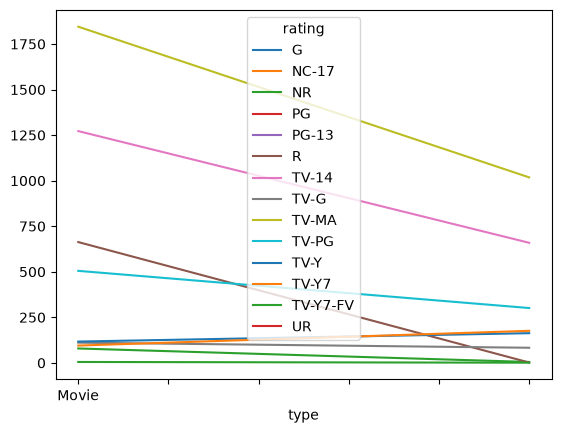

In [19]:
pata.groupby(["type", "rating"]).size().unstack().plot(kind="line")